# Soft Edged Apertures

Here is a simpler method to just use a sigmoid to soften the edge of an aperture.

In [15]:
import warnings
warnings.filterwarnings("ignore") # lots of functions are under development

import jax
from jax.config import config
import jax.numpy as np
from jax import vmap, jit
config.update("jax_enable_x64", True)

from jax.nn import sigmoid, silu, hard_sigmoid, gelu, soft_sign

import numpy as onp
import matplotlib.pyplot as plt

from tqdm import tqdm

%matplotlib inline
plt.rcParams['image.cmap'] = 'hot'
plt.rcParams["text.usetex"] = 'false'
plt.rcParams['figure.dpi'] = 120

Create a grid:

In [2]:
x = np.arange(-128,128)
xx, yy = np.meshgrid(x,x)
rr = np.sqrt(xx**2 + yy**2)

Make a hard edged circle:

In [3]:
rad = 128.-32.

circ = np.array((rr-rad)<0,dtype=np.float64)

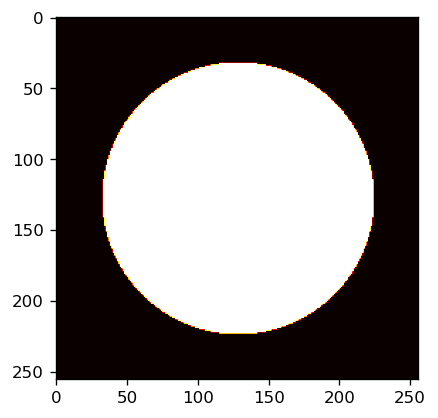

In [4]:
plt.imshow(circ)

Let's test a couple of common activation functions - the sigmoid, and the piecewise 'hard sigmoid' that just linearly maps between 0 and 1. We want to create a unit sigmoid that starts at 0 and reaches 1 at/near 1, rather than the default which does it symmetrically around 0 and takes 6 to reach max. This way, if we want to include an `edge_size` we can just rescale this from unity. 

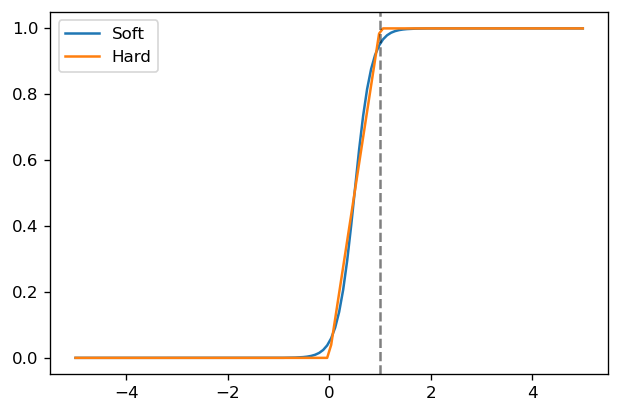

In [16]:
t = np.linspace(-5,5,128)

plt.plot(t,sigmoid((t-0.5)*6),label='Soft')
plt.plot(t,hard_sigmoid((t-0.5)*6),label='Hard')
plt.axvline(1,color='k',linestyle='--',alpha=0.5)
plt.legend()
# plt.plot(t,gelu(t+1))

# plt.plot(t,silu(t+1))


Let's define these rescaled sigmoids as functions:

In [7]:
def soft_thresh(a):
    return hard_sigmoid((a-0.5)*6)

def softer_thresh(a):
    return sigmoid((a-0.5)*6)

Now instead of just testing for inequality, we can just test for 

In [8]:
soft_circ = np.array(soft_thresh(rr-rad))
softer_circ = np.array(softer_thresh(rr-rad))

(200.0, 250.0)

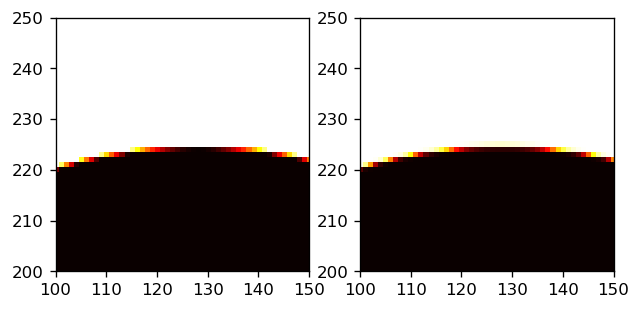

In [20]:
fig, (ax1,ax2) = plt.subplots(1,2)
ax1.imshow(soft_circ)
ax1.set_xlim(100,150)
ax1.set_ylim(200,250)
ax2.imshow(softer_circ)
ax2.set_xlim(100,150)
ax2.set_ylim(200,250)

Calculate gradients!

In [22]:
from jax import grad, jacobian, jacfwd

In [23]:
@jit
def make_soft_circ(rad):
    return np.array(soft_thresh(rr-rad))

@jit
def make_softer_circ(rad):
    return np.array(softer_thresh(rr-rad))

In [27]:
grad_soft = jacfwd(make_soft_circ) # use forwards mode or else it will suck
grad_norm = grad(lambda x: np.sum(make_soft_circ(x))) # try scalar 

In [28]:
%%time
grad_norm(rad) # scalar

CPU times: user 11.6 ms, sys: 4.1 ms, total: 15.7 ms
Wall time: 16.3 ms


DeviceArray(-604., dtype=float64, weak_type=True)

In [29]:
%%time
grad_soft(rad) # vector

CPU times: user 9.9 ms, sys: 3.64 ms, total: 13.5 ms
Wall time: 14 ms


DeviceArray([[-0., -0., -0., ..., -0., -0., -0.],
             [-0., -0., -0., ..., -0., -0., -0.],
             [-0., -0., -0., ..., -0., -0., -0.],
             ...,
             [-0., -0., -0., ..., -0., -0., -0.],
             [-0., -0., -0., ..., -0., -0., -0.],
             [-0., -0., -0., ..., -0., -0., -0.]], dtype=float64)

Now do this with a finite edge size:

In [41]:
edge = 2.0

@jit
def make_soft_edge(rad):
    return np.array(soft_thresh((rr-rad)/edge))

@jit
def make_softer_edge(rad):
    return np.array(softer_thresh((rr-rad)/edge))

(200.0, 250.0)

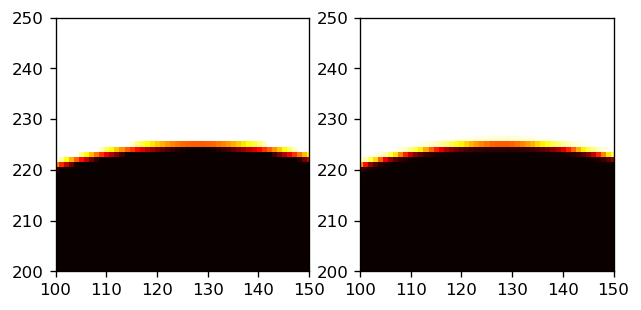

In [42]:
fig, (ax1,ax2) = plt.subplots(1,2)

ax1.imshow(make_soft_edge(rad))
ax1.set_xlim(100,150)
ax1.set_ylim(200,250)
ax2.imshow(make_softer_edge(rad))
ax2.set_xlim(100,150)
ax2.set_ylim(200,250)

In [44]:
grad_soft_edge = jacfwd(make_soft_edge) # use forwards mode or else it will suck
grad_softer_edge = jacfwd(make_softer_edge)
grad_norm_edge = grad(lambda x: np.sum(make_soft_edge(x))) # try scalar 

In [45]:
%%time
grad_norm_edge(rad) # scalar

CPU times: user 111 ms, sys: 5 ms, total: 116 ms
Wall time: 111 ms


DeviceArray(-616., dtype=float64, weak_type=True)

In [46]:
%%time
grad_soft_edge(rad) # vector

CPU times: user 80.1 ms, sys: 5.73 ms, total: 85.9 ms
Wall time: 86.9 ms


DeviceArray([[-0., -0., -0., ..., -0., -0., -0.],
             [-0., -0., -0., ..., -0., -0., -0.],
             [-0., -0., -0., ..., -0., -0., -0.],
             ...,
             [-0., -0., -0., ..., -0., -0., -0.],
             [-0., -0., -0., ..., -0., -0., -0.],
             [-0., -0., -0., ..., -0., -0., -0.]], dtype=float64)

Let's visualize this:

(200.0, 250.0)

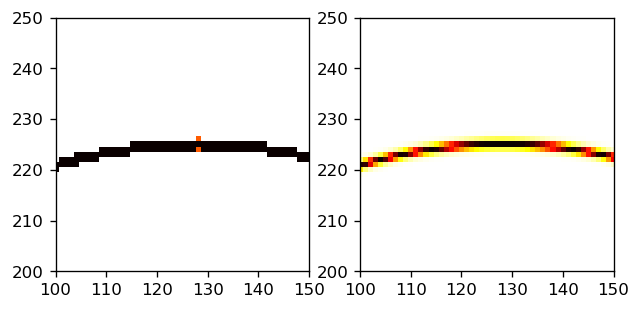

In [47]:
fig, (ax1,ax2) = plt.subplots(1,2)

ax1.imshow(grad_soft_edge(rad))
ax1.set_xlim(100,150)
ax1.set_ylim(200,250)
ax2.imshow(grad_softer_edge(rad))
ax2.set_xlim(100,150)
ax2.set_ylim(200,250)

I reckon the `sigmoid` softer edge looks like it is going to be more numerically stable. 